# Game Player Analysis — revue Data Science finale

**Livrable principal exécuté.** L'objectif officiel est de prédire
`winRankPercentage`, le score de classement de l'équipe du joueur normalisé
entre 0 (dernière place) et 1 (première place), à partir de statistiques
post-partie. Une ligne décrit un joueur, tandis que la cible d'équipe est
répétée sur les joueurs observés de cette équipe.

Ce notebook privilégie la justesse des interprétations et la traçabilité :
chaque résultat modélisé est out-of-fold, le `gameId` est groupé, et le fichier
test officiel de mai reste sans labels et hors de toute sélection de modèle.

## 1. Cadre officiel, métrique et questions

- **Train :** 50 000 lignes attribuées à janvier–avril 2024.
- **Test :** 5 000 lignes attribuées à mai 2024.
- **Métrique principale :** MAE, complétée par RMSE et R².
- **Question modèle :** quelle précision post-match obtient-on avec les
  variables individuelles, et quelle part provient de `killRank` ?
- **Question produit :** les comportements mobilité, combat et ressources
  restent-ils informatifs sans le classement post-match ?

Le sujet affirme que `date` est la date du match. Cette définition sera testée,
pas supposée vraie. `maxRank` définit la grille de classement déclarée ; ce
n'est ni le nombre réel de joueurs ni le nombre de lignes observées par match.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/game-player-analysis-matplotlib")

import pandas as pd
from IPython.display import Image, Markdown, display

from game_player_analysis.inference import predict_frame
from game_player_analysis.logging_config import configure_logging
from game_player_analysis.pipeline import run_final_analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
configure_logging()

<Logger game_player_analysis (INFO)>

## 2. Exécution reproductible du pipeline

La cellule suivante repart des CSV bruts et exécute une seule chaîne commune :
validation, nettoyage, EDA, feature engineering, GroupKFold, quatre ensembles,
tuning borné, ablations, diagnostics, modèle final, manifeste et soumission.
La seed vaut 42 ; les empreintes SHA-256 des données sont conservées dans le
manifeste.

In [2]:
results = run_final_analysis(tuning_iterations=6)
tables = results["tables"]
display(Markdown(f"**Modèle publié : {results['winner']}**"))

2026-08-02T09:35:36 | INFO | game_player_analysis.pipeline | Loading and validating official train/test files


2026-08-02T09:35:38 | INFO | game_player_analysis.pipeline | Benchmarking baselines and four ensemble families


2026-08-02T09:37:34 | INFO | game_player_analysis.pipeline | Running bounded XGBoost tuning (6 trials)


2026-08-02T09:37:41 | INFO | game_player_analysis.modeling | Tuning trial 1/6: MAE 0.063113


2026-08-02T09:37:50 | INFO | game_player_analysis.modeling | Tuning trial 2/6: MAE 0.061767


...

2026-08-02T09:38:08 | INFO | game_player_analysis.modeling | Tuning trial 6/6: MAE 0.064972


2026-08-02T09:38:16 | INFO | game_player_analysis.pipeline | Auditing feature families, splits, errors and interpretability


2026-08-02T09:39:15 | INFO | game_player_analysis.pipeline | Fitting and publishing XGBoost


2026-08-02T09:39:16 | INFO | game_player_analysis.pipeline | Analysis complete: MAE 0.061650


**Modèle publié : XGBoost**

## 3. Chargement, contrat de données et nettoyage

In [3]:
display(tables["dataset_summary"])
display(tables["data_quality"].pivot(index="check", columns="dataset", values="rows"))

,train,test
rows,50000,5000
columns,30,29
matches,30983,4431
game_modes,16,10
missing_cells,0,0
exact_duplicates,0,0
date_min,2024-01-01 00:00:00,2024-05-01 00:00:00
date_max,2024-04-30 00:00:00,2024-05-31 00:00:00
has_target,True,False


dataset,test,train
check,,
combat_without_distance,5,102
exact_duplicates,0,0
invalid_gameId,10,93
invalid_playerId,14,93
invalid_teamId,8,87
killPts_conditional_zero,3000,29840
kills_without_damage,5,53
missing_cells,0,0
rankPts_-1,1888,19191


Il n'y a ni valeur manquante brute ni doublon exact. Cela ne signifie pas que
toutes les valeurs sont sémantiquement disponibles : `rankPts=-1` est une
sentinelle documentée ; `killPts=0` et `winPts=0` sont manquants lorsque le
système `rankPts` est actif. Le nettoyage les convertit en valeurs absentes et
ajoute des indicateurs, sans supprimer de ligne. Ces scores ne sont pas retenus
dans le modèle final, ce qui évite de mélanger plusieurs systèmes de ranking.

,dataset,check,rows,pct
2,train,invalid_playerId,93,0.186000
3,train,invalid_teamId,87,0.174000
4,train,invalid_gameId,93,0.186000
5,train,rankPts_-1,19191,38.382000
6,train,killPts_conditional_zero,29840,59.680000
7,train,winPts_conditional_zero,29840,59.680000
8,train,kills_without_damage,53,0.106000
9,train,combat_without_distance,102,0.204000
12,test,invalid_playerId,14,0.280000
13,test,invalid_teamId,8,0.160000


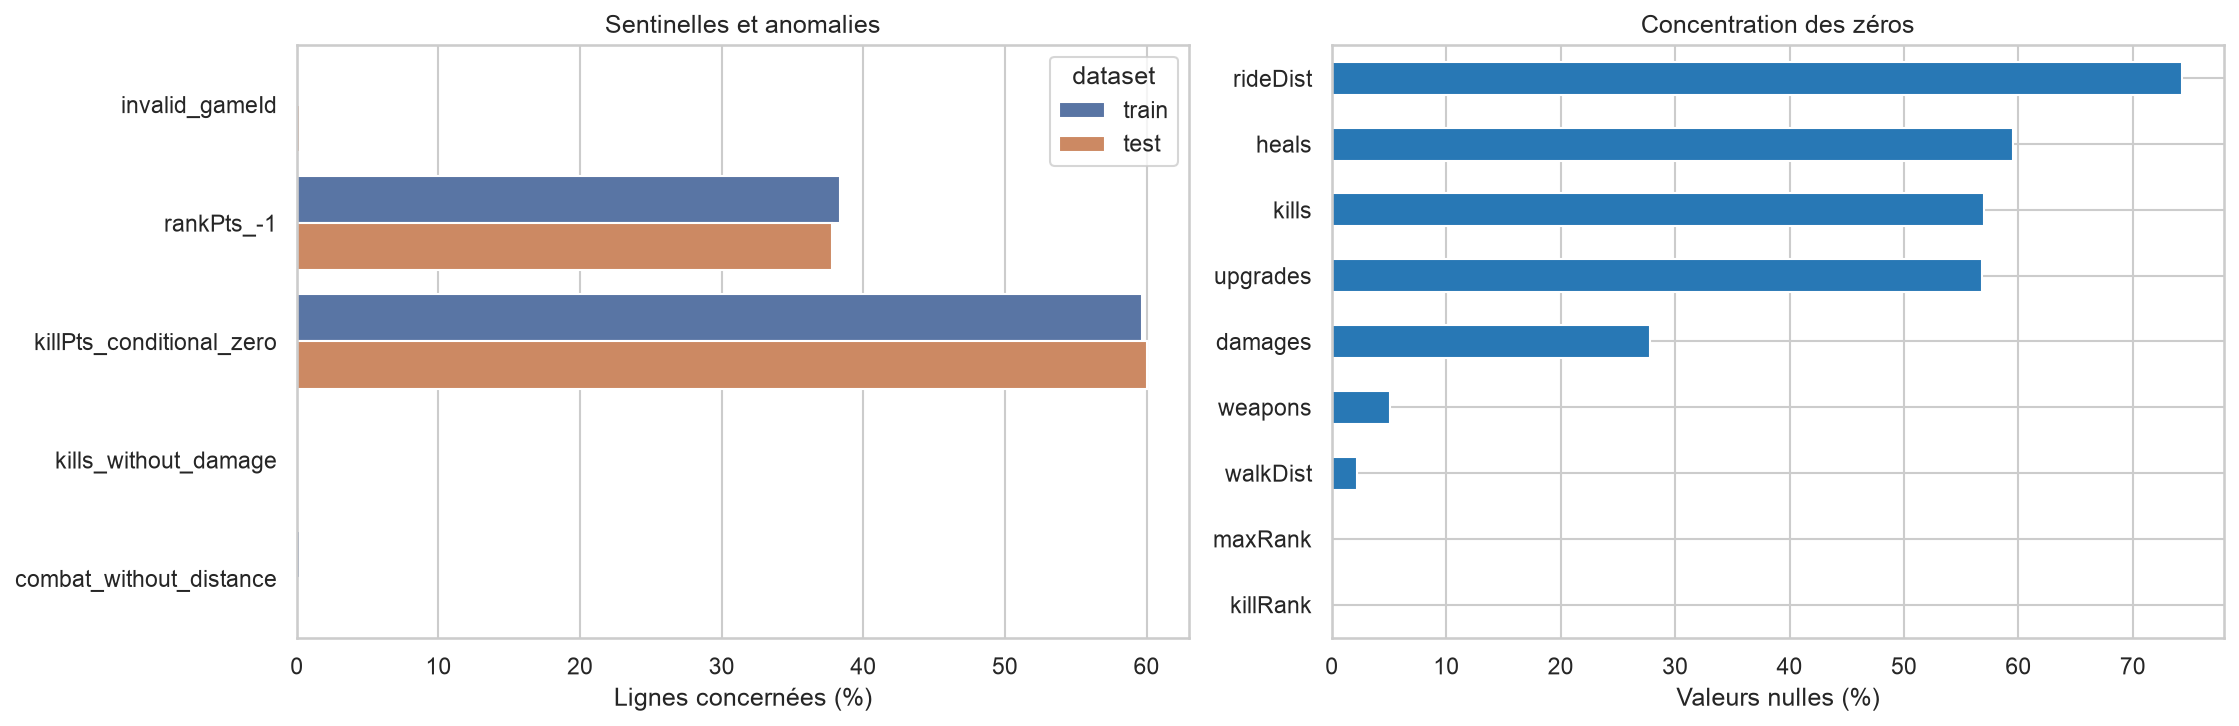

In [4]:
quality = tables["data_quality"]
display(quality.loc[quality["check"].str.contains("Pts|without|invalid")])
display(Image(filename=str(results["paths"]["figure_data_quality"])))

## 4. Audit de la date et de l'échantillonnage

,rows,valid_game_ids,games,multirow_games,multirow_games_with_multiple_dates_pct,median_within_game_span_days,p95_within_game_span_days,max_within_game_span_days,date_min,date_max,unique_dates
dataset,,,,,,,,,,,
train,50000,49907,30927,13464,100.000000,45.026931,99.528735,119.302646,2024-01-01,2024-04-30,50000
test,5000,4990,4425,521,100.000000,9.067814,22.930586,28.949790,2024-05-01,2024-05-31,5000


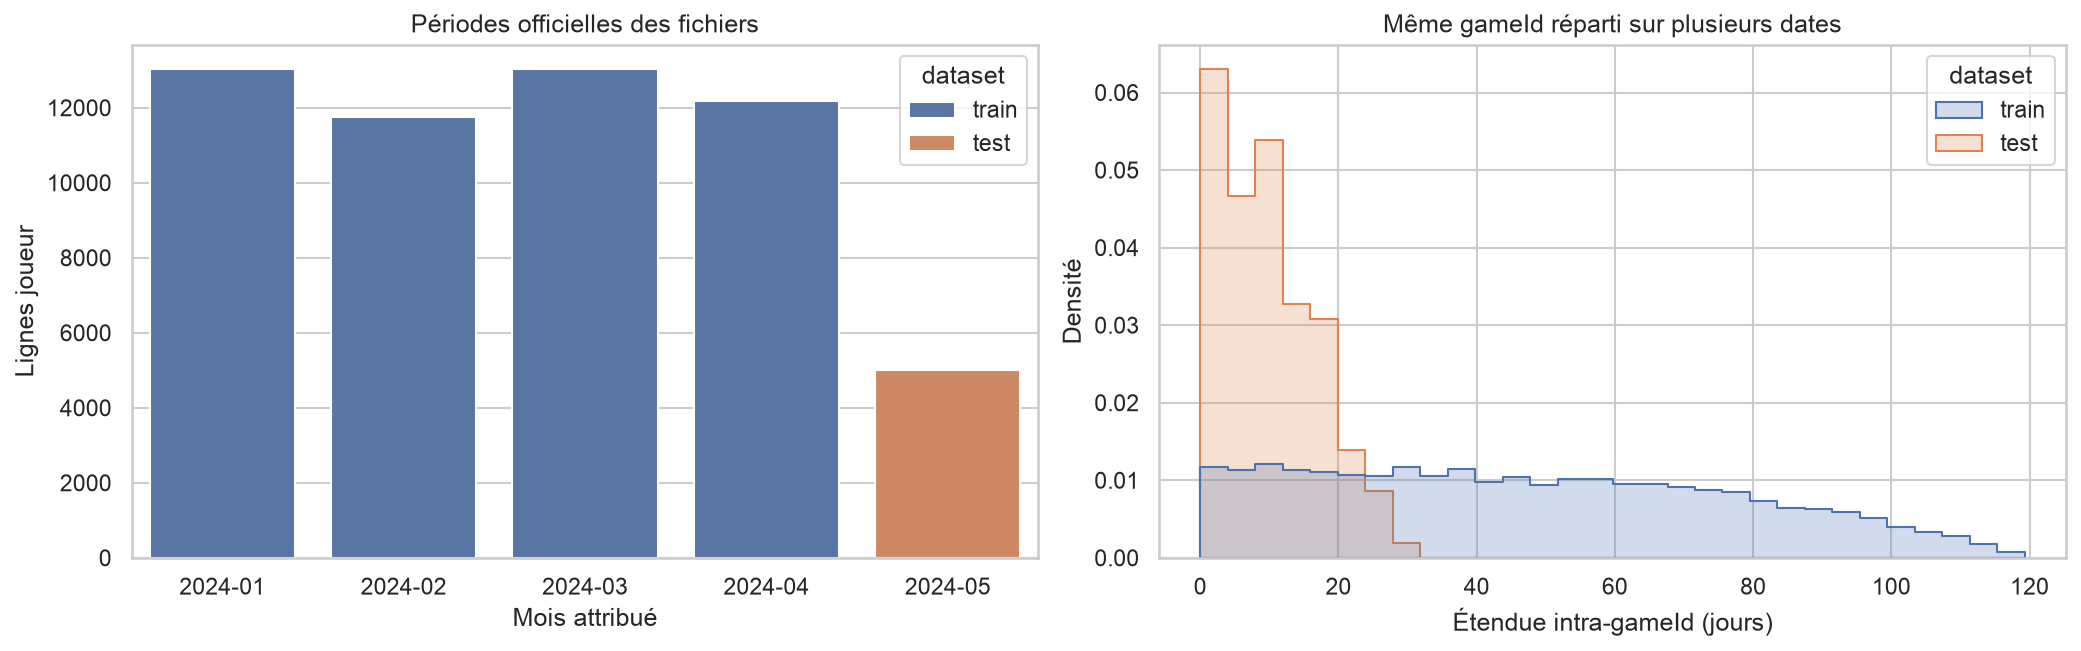

In [5]:
display(tables["date_integrity"])
display(Image(filename=str(results["paths"]["figure_date_integrity"])))

**Conclusion de l'audit temporel.** Pour 100 % des `gameId` valides ayant
plusieurs lignes, les dates diffèrent entre joueurs ; l'étendue médiane atteint
environ 45 jours dans le train. Les dates sont donc incompatibles avec la
définition officielle au niveau ligne. La cause technique n'est pas observable
dans les fichiers : on les qualifie d'incohérentes/corrompues, sans inventer une
explication. Le temps ne devient qu'un stress test pseudo-temporel.

,games,mean_observed_players_per_game,max_observed_players_per_game,observed_game_teams,singleton_team_pct,rows_with_observed_teammate_pct
dataset,,,,,,
train,30983,1.613788,8,49411,98.824148,2.340000
test,4431,1.128413,4,4974,99.477282,1.040000


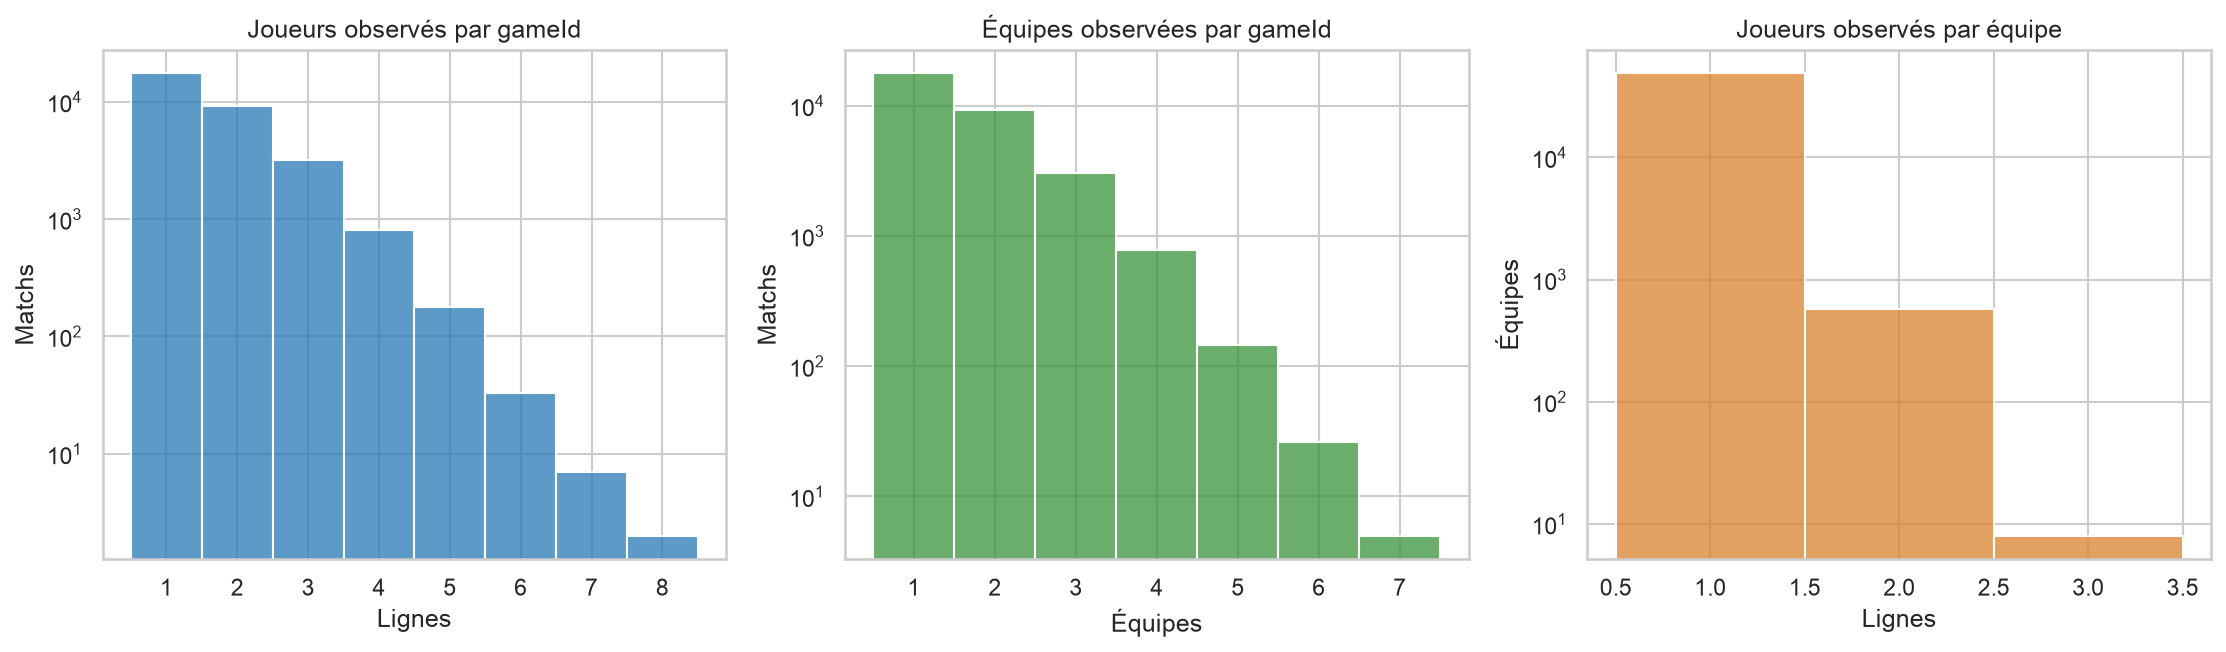

In [6]:
display(tables["sampling_coverage"])
display(Image(filename=str(results["paths"]["figure_sampling"])))

Seulement ~2,34 % des lignes train ont un coéquipier observé et près de 98,82 %
des groupes `(gameId, teamId)` sont des singletons. Les agrégats équipe/lobby
sont donc **rejetés** : ils mesureraient surtout le mécanisme d'échantillonnage,
pas la performance complète de l'équipe.

## 5. Analyse exploratoire et hypothèses

,valeur
target_mean,0.472333
target_median,0.457850
target_std,0.307449
target_zero_rows,"2,450.000000"
target_one_rows,"1,430.000000"
unique_target_values,"1,445.000000"
grid_distance_median,0.000800
grid_distance_p95,0.003200
grid_distance_max,0.005000
rows_within_0.0001_of_grid,"10,380.000000"


,zero_pct,mean,median,p95,p99,max,spearman_target
walkDist,2.204000,"1,155.221535",683.750000,"3,384.000000","4,395.020000","11,260.000000",0.866437
killRank,0.000000,47.576260,47.000000,91.000000,96.000000,100.000000,-0.714684
upgrades,56.864000,1.104860,0.000000,5.000000,7.000000,14.000000,0.681032
weapons,5.116000,3.664060,3.000000,8.000000,10.000000,73.000000,0.664606
heals,59.542000,1.376980,0.000000,7.000000,13.000000,41.000000,0.563679
damages,27.810000,130.002242,84.700000,457.000000,766.602000,"3,725.000000",0.449022
rideDist,74.258000,602.279772,0.000000,"4,032.000000","6,868.100000","31,290.000000",0.432890
kills,56.966000,0.921040,0.000000,4.000000,7.000000,35.000000,0.424812
maxRank,0.000000,44.396660,30.000000,97.000000,99.000000,100.000000,0.045750


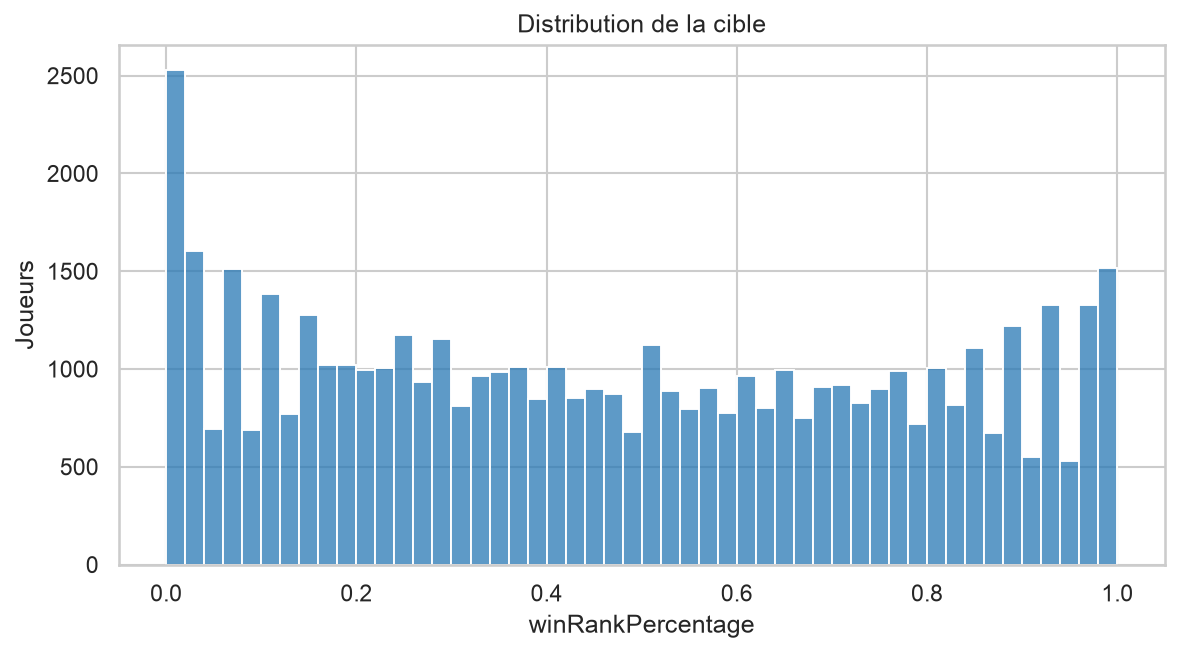

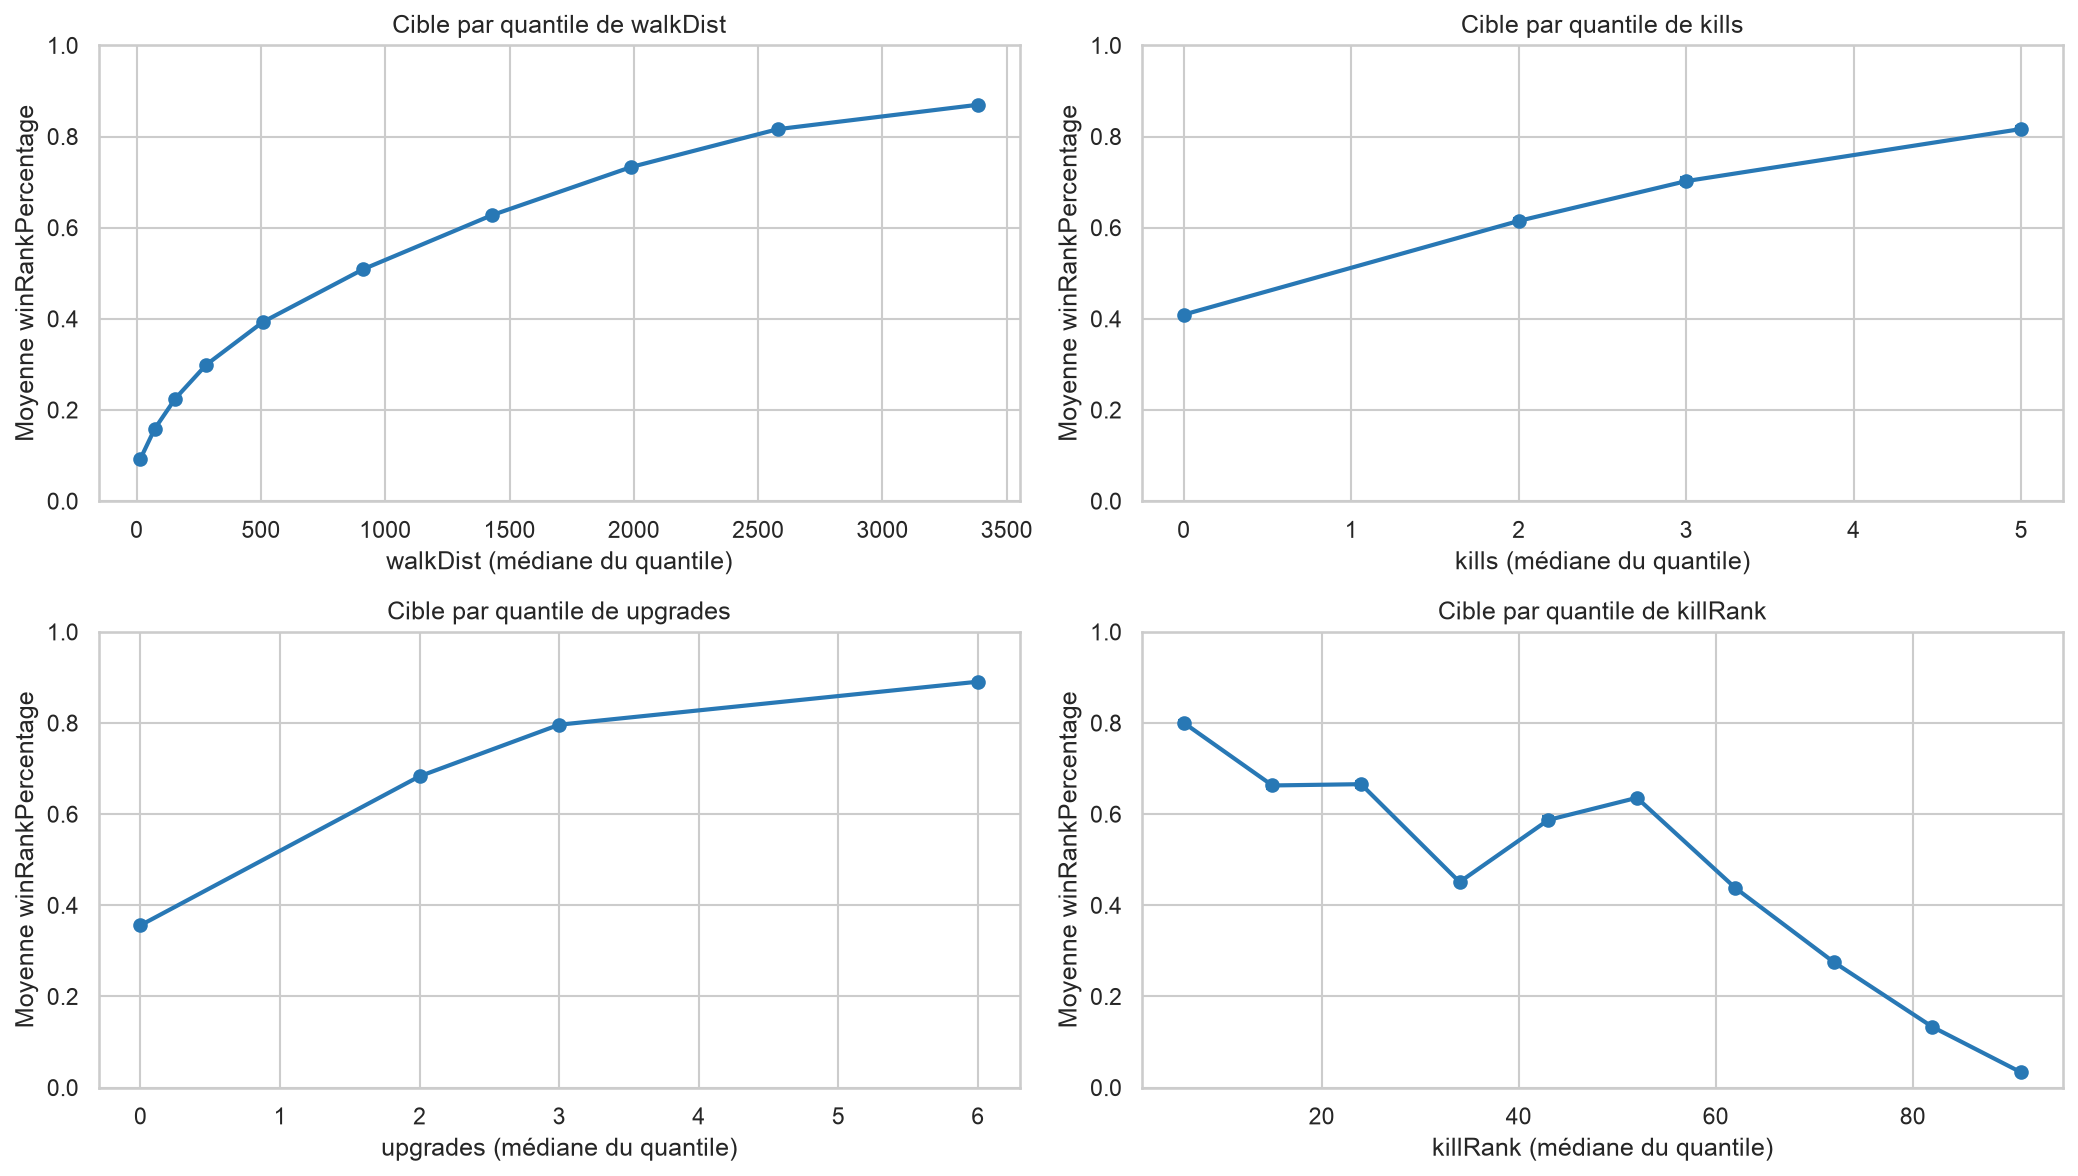

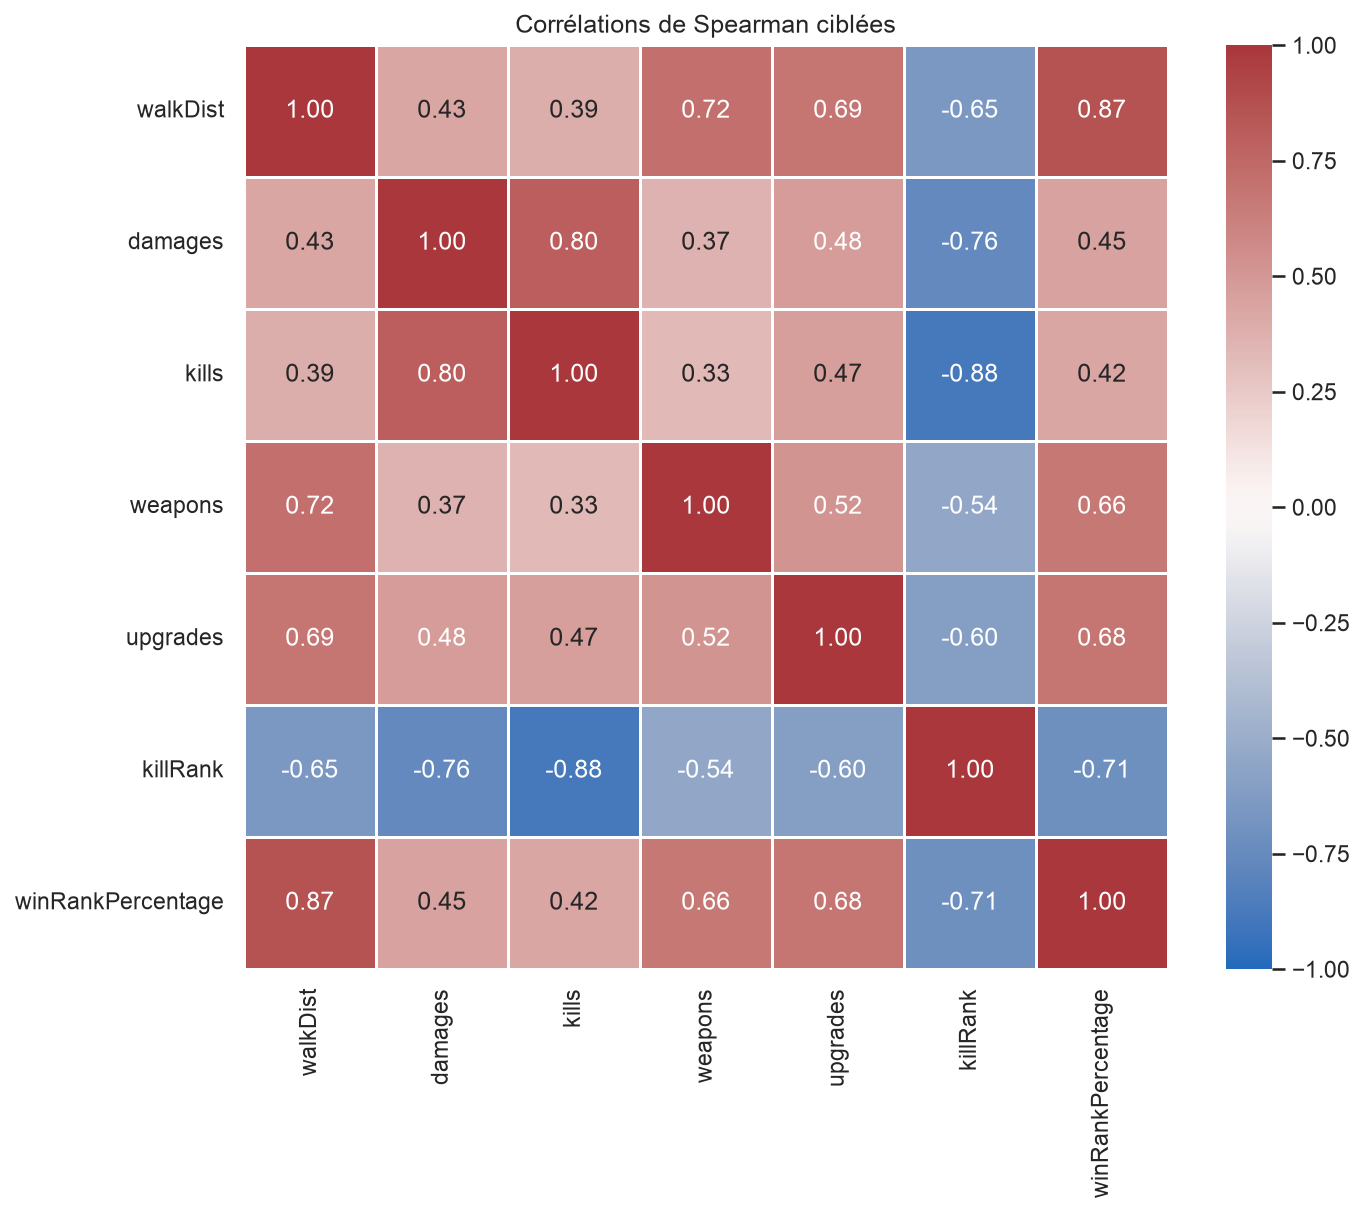

In [7]:
display(tables["target_grid"].to_frame("valeur"))
display(tables["numeric_profile"])
display(Image(filename=str(results["paths"]["figure_target"])))
display(Image(filename=str(results["paths"]["figure_profiles"])))
display(Image(filename=str(results["paths"]["figure_correlations"])))

Hypothèses examinées : (1) la mobilité reflète fortement la progression dans
la partie ; (2) combat et ressources ajoutent une information comportementale ;
(3) `killRank`, déjà calculé après le match, doit dominer le scénario post-match ;
(4) les modes changent l'échelle des comportements. Les profils par quantiles
et leurs intervalles à 95 % montrent les relations non linéaires ; la matrice
de Spearman reste ciblée pour ne pas masquer ces effets.

## 6. KPI analytiques

In [8]:
display(tables["kpi_evaluation"])

,formula,defined_pct,mean,median,p95,zero_pct_among_defined,spearman_target,most_redundant_source,max_abs_source_spearman,model_decision
kpi,,,,,,,,,,
total_distance,walkDist + rideDist + swimDist,100.000000,"1,761.907329",792.000000,"6,430.050000",2.136000,0.832147,walkDist,0.943067,analytic_only_redundant
mobility_per_match_second,total_distance / gameTime,100.000000,1.074005,0.510672,3.519943,2.136000,0.848123,total_distance,0.994194,analytic_only_match_time_not_survival
damage_per_kill_kpi,damages / kills; 0 when kills=0,100.000000,53.572314,0.000000,190.600000,57.072000,0.369443,kills,0.890303,candidate_requires_ablation
headshot_ratio,headshots / kills; undefined when kills=0,43.034000,0.236041,0.000000,1.000000,61.026165,0.106378,headshots,0.942995,analytic_only_sparse
combat_activity_kpi,kills + assists + knocks,100.000000,1.809560,1.000000,7.000000,45.468000,0.429753,kills,0.900159,candidate_requires_ablation
resource_activity_kpi,weapons + upgrades + heals,100.000000,6.145900,5.000000,17.000000,5.078000,0.771366,weapons,0.861983,candidate_requires_ablation
support_actions,assists + revives,100.000000,0.396940,0.000000,2.000000,74.168000,0.363548,assists,0.794826,analytic_only_mode_dependent


Chaque ratio a une règle explicite pour les dénominateurs nuls. Les KPI
`total_distance`, mobilité/seconde et headshot ratio restent descriptifs car
ils sont redondants, utilisent `gameTime` qui n'est pas un temps de survie, ou
sont trop clairsemés. `damage_per_kill`, `combat_activity` et
`resource_activity` entrent dans l'ablation : leur maintien dépend de leur gain
mesuré, pas de leur plausibilité seule.

## 7. Features et ablation progressive

,model,mae,mae_std,rmse,r2,train_mae,fit_seconds,predict_seconds,feature_count,overfitting,mae_gain_vs_previous
stage,,,,,,,,,,,
1. context,1. context,0.267786,0.001587,0.307341,0.000625,0.266950,4.872859,0.111084,4,faible écart,NaN
2. + mobility,2. + mobility,0.099066,0.000968,0.136052,0.804148,0.092017,5.778772,0.126799,7,écart modéré,0.168720
3. + combat,3. + combat,0.096156,0.000671,0.132953,0.812974,0.086193,8.599401,0.180805,11,écart modéré,0.002910
4. + resources,4. + resources,0.093264,0.001042,0.130392,0.820097,0.082441,7.140841,0.145488,15,écart modéré,0.002892
5. + killRank post-match,5. + killRank post-match,0.061604,0.000607,0.086692,0.920484,0.052583,8.889443,0.237961,16,écart modéré,0.031661


,mae,rmse,r2,features
scenario,,,,
post_match_with_killRank,0.061650,0.086796,0.920300,16
behavior_without_killRank,0.093264,0.130392,0.820097,15
post_match_grid_snapped,0.061211,0.087509,0.918984,16


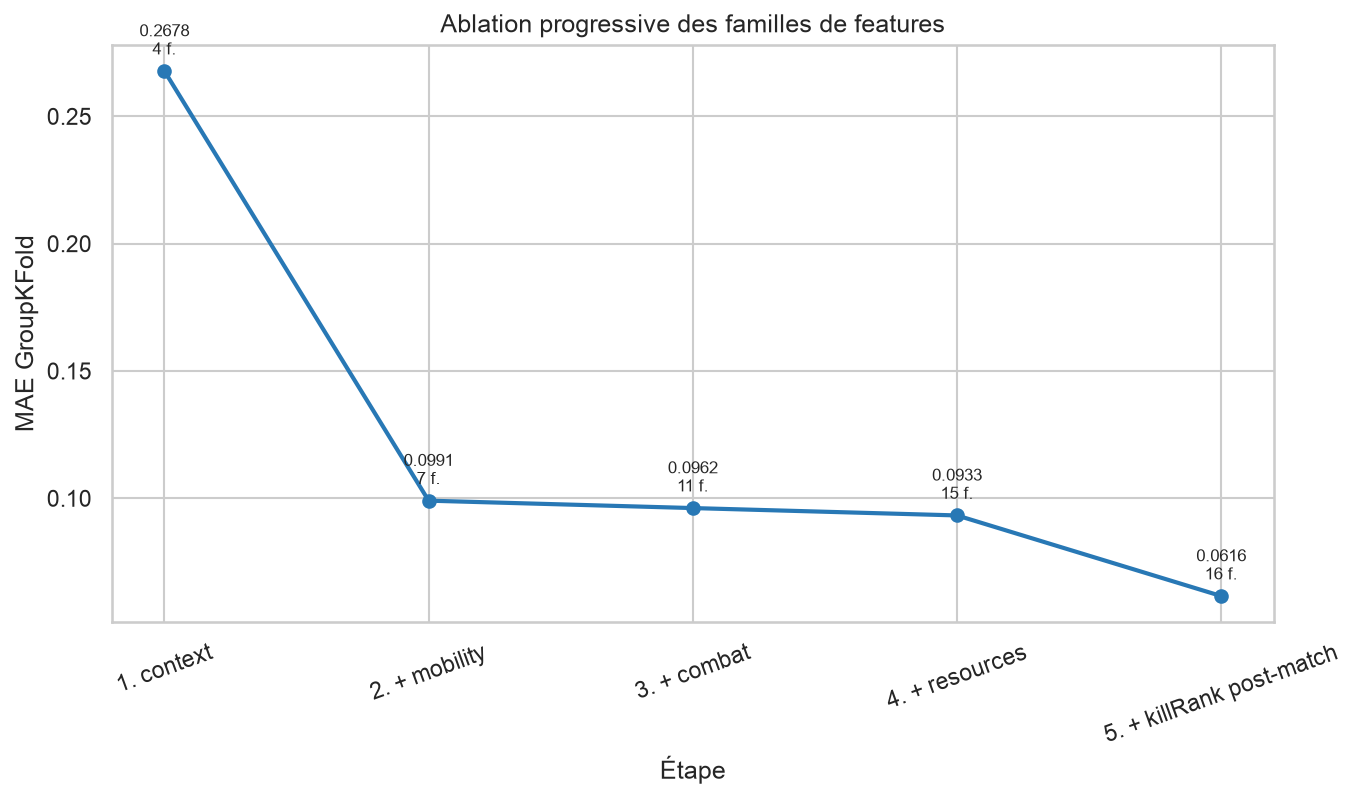

In [9]:
display(tables["feature_ablation"].set_index("stage"))
display(tables["scenario_comparison"].set_index("scenario"))
display(Image(filename=str(results["paths"]["figure_ablation"])))

La mobilité produit le principal gain comportemental ; combat et ressources
améliorent ensuite modestement la MAE. L'ajout de `killRank` fait passer la MAE
d'environ 0,0933 à 0,0616 : le modèle publié est donc explicitement un modèle
**post-match**, et non une prédiction early-game. La projection sur la grille
`maxRank` améliore légèrement la MAE mais dégrade le RMSE ; elle est réservée à
la soumission, avec cette contrepartie documentée.

## 8. Validation et contrôles de fuite

,fold,train_rows,validation_rows,shared_groups,shared_raw_game_ids,invalid_train_rows,invalid_validation_rows
0,1,40000,10000,0,0,74,19
1,2,40000,10000,0,0,74,19
2,3,40000,10000,0,0,76,17
3,4,40000,10000,0,0,76,17
4,5,40000,10000,0,0,72,21


,train_rows,validation_rows,shared_groups,shared_raw_game_ids,validation_rows_from_seen_games_pct,train_date_min,train_date_max,validation_date_min,validation_date_max
strategy,,,,,,,,,
Random row,40000,10000,5114,5114,56.640000,2024-01-01,2024-04-30 00:00:00.000000000,2024-01-01 00:13:42.544450889,2024-04-29 23:36:00.547210944
Grouped gameId,39901,10099,0,0,0.000000,2024-01-01,2024-04-29 23:56:34.363887278,2024-01-01 00:10:16.908338166,2024-04-30 00:00:00.000000000
Naive Jan-Mar → Apr,37815,12185,5908,5908,54.969224,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000
Purged Jan-Mar → Apr,29279,12185,0,0,0.000000,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000


,train_rows,validation_rows,train_mae,mae,rmse,r2,fit_seconds,predict_seconds
strategy,,,,,,,,
Random row,40000,10000,0.052691,0.061688,0.086836,0.921273,1.428989,0.030406
Grouped gameId,39901,10099,0.052644,0.061680,0.086423,0.920812,1.468574,0.028904
Naive Jan-Mar → Apr,37815,12185,0.052473,0.061694,0.086521,0.921467,1.361832,0.030880
Purged Jan-Mar → Apr,29279,12185,0.050911,0.062216,0.087217,0.920198,1.327727,0.031867


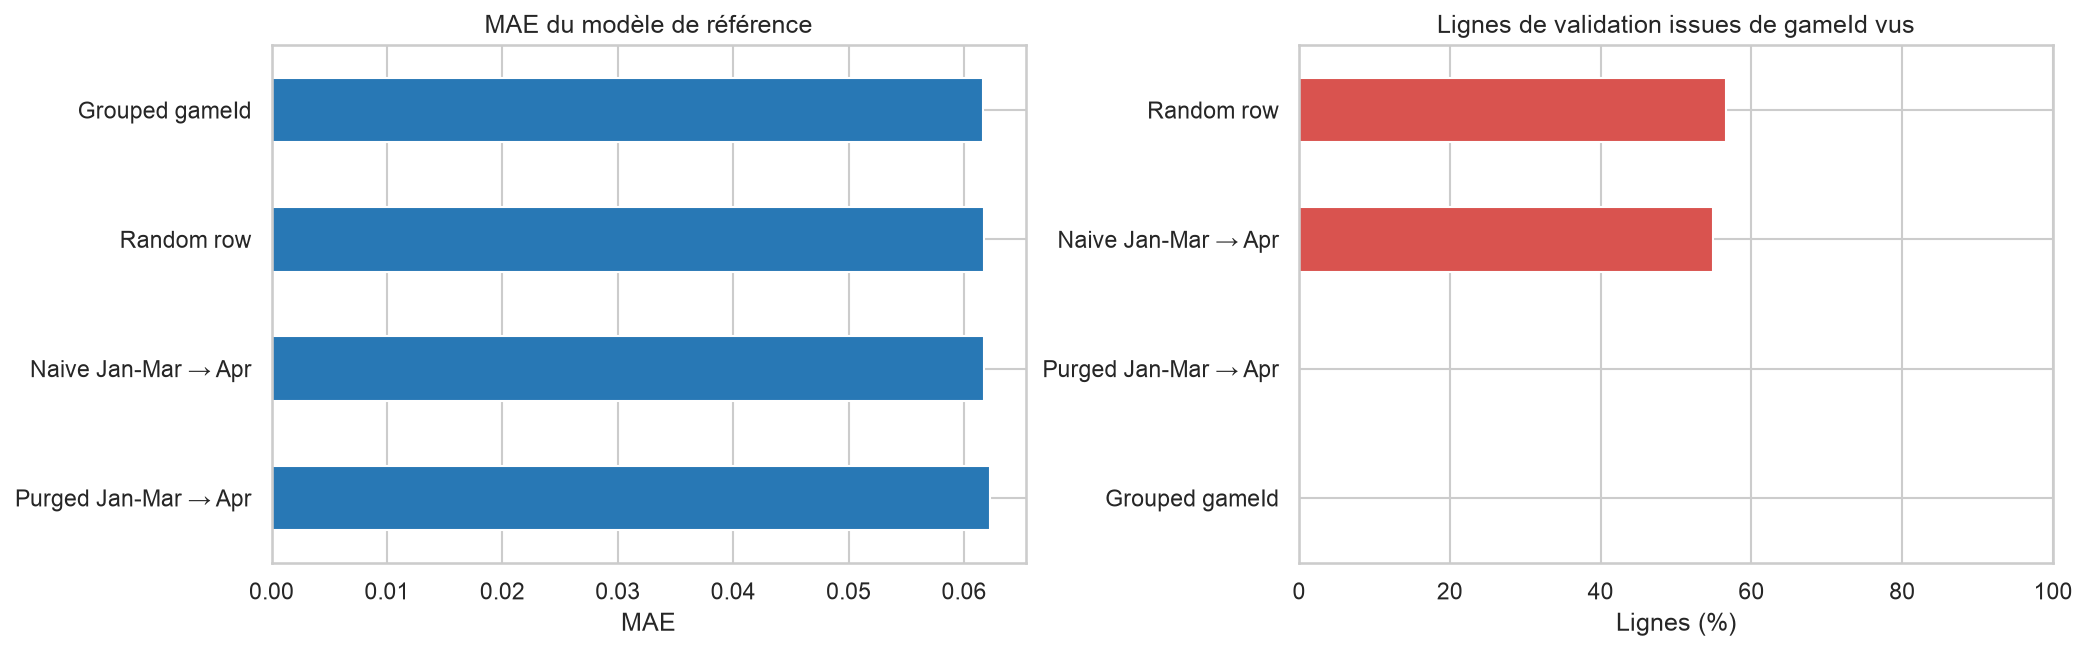

In [10]:
display(tables["fold_audit"])
display(tables["holdout_audit"])
display(tables["holdout_performance"])
display(Image(filename=str(results["paths"]["figure_validation"])))

Le protocole principal est un GroupKFold à 5 folds sur `gameId`. Les valeurs
malformées répétées sont groupées conservativement ; aucune valeur brute ni
groupe synthétique ne traverse un fold. Un split aléatoire de lignes expose
plus de la moitié de sa validation à des matchs déjà vus. Le stress test
Jan–mars → avril purge 8 536 lignes partageant un match avec avril ; sa MAE un
peu plus élevée mesure la robustesse, mais ne valide pas la chronologie puisque
`date` est incohérente.

## 9. Baselines et comparaison des modèles

,model,mae,mae_std,rmse,r2,train_mae,fit_seconds,predict_seconds,feature_count,overfitting
rank,,,,,,,,,,
1,XGBoost,0.061650,0.000629,0.086793,0.920296,0.052609,8.894726,0.164291,16,écart modéré
2,LightGBM,0.061685,0.000577,0.086764,0.920352,0.055311,19.951567,0.558008,16,écart modéré
3,CatBoost,0.061703,0.000593,0.086556,0.920729,0.058856,17.197498,0.044794,16,faible écart
4,XGBoost tuned,0.061767,0.000565,0.086926,0.920053,0.054089,7.138991,0.145387,16,écart modéré
5,Random Forest,0.065421,0.000580,0.092475,0.909518,0.030333,61.051047,1.115256,16,écart élevé
6,Linear Ridge baseline,0.088226,0.000858,0.122301,0.841749,0.088172,0.059482,0.009855,16,faible écart
7,Median baseline,0.267986,0.001762,0.307810,-0.002422,0.267983,0.000000,0.000000,16,non applicable
8,Mean baseline,0.268248,0.001708,0.307447,-0.000063,0.268246,0.000000,0.000000,16,non applicable


,reference_model,candidate_model,folds,mean_mae_difference,ci95_lower,ci95_upper,candidate_worse_folds
0,XGBoost,LightGBM,5,0.000035,-0.000066,0.000127,3
1,XGBoost,CatBoost,5,0.000053,-0.000103,0.000226,2
2,XGBoost,XGBoost tuned,5,0.000117,0.000033,0.000232,4
3,XGBoost,Random Forest,5,0.003771,0.003695,0.003846,5
4,XGBoost,Linear Ridge baseline,5,0.026576,0.026038,0.027171,5
5,XGBoost,Median baseline,5,0.206337,0.204807,0.207700,5
6,XGBoost,Mean baseline,5,0.206598,0.205114,0.207947,5


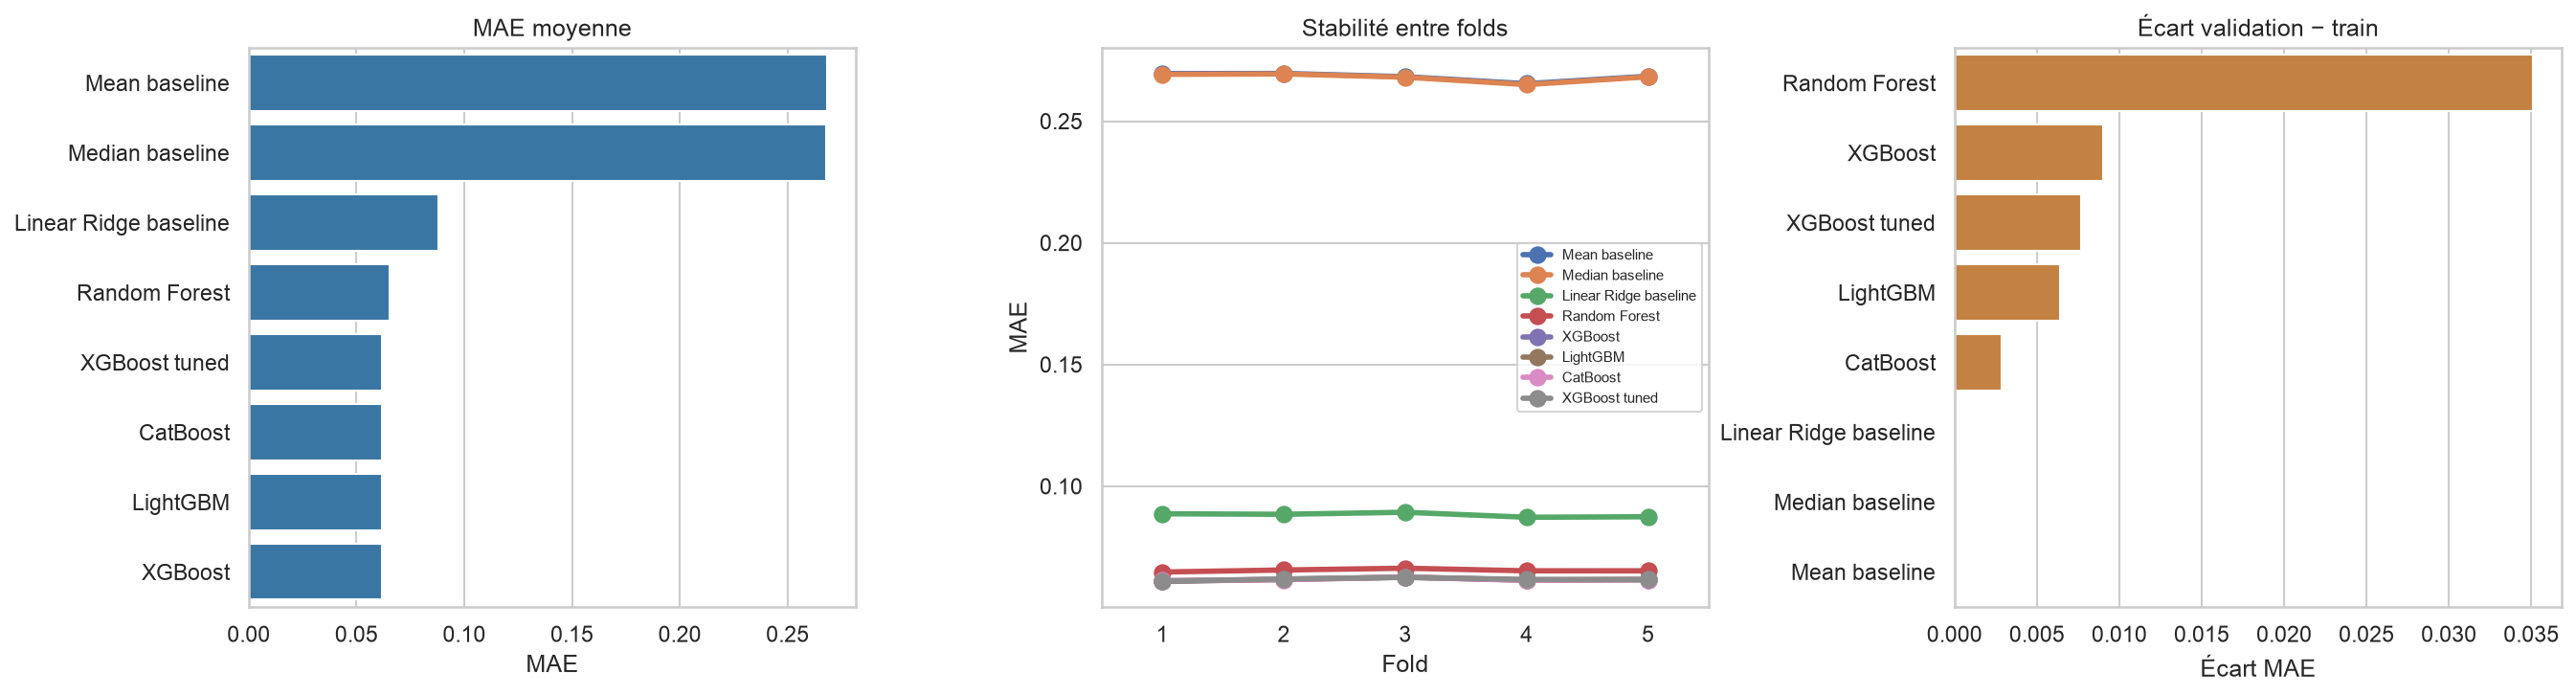

In [11]:
display(tables["model_comparison"].set_index("rank"))
display(tables["model_fold_uncertainty"])
display(Image(filename=str(results["paths"]["figure_models"])))

Les moyennes/médianes constantes et Ridge constituent les baselines. Les trois
meilleurs ensembles sont séparés par moins d'un écart-type de fold : XGBoost
est retenu pour sa meilleure MAE, mais on ne prétend pas qu'il domine
structurellement LightGBM et CatBoost. Random Forest présente le plus grand
écart train/validation et un coût d'ajustement supérieur.

## 10. Tuning borné et décision anti-surajustement

,trial,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,mae,mae_std,rmse,r2,train_mae,fit_seconds,predict_seconds,feature_count,overfitting
0,2,1.000000,10.000000,0.100000,500,1,6,0.050000,1.000000,0.061767,0.000565,0.086926,0.920053,0.054089,8.753300,0.156493,16,écart modéré
1,5,0.850000,1.000000,0.500000,500,3,4,0.080000,0.850000,0.062027,0.000518,0.087105,0.919723,0.058280,4.923243,0.092575,16,écart modéré
2,3,0.750000,10.000000,0.100000,500,3,4,0.050000,1.000000,0.063041,0.000470,0.088412,0.917297,0.060300,5.639916,0.106818,16,faible écart
3,1,1.000000,5.000000,0.500000,500,3,4,0.050000,0.750000,0.063113,0.000442,0.088505,0.917125,0.060510,5.833941,0.121005,16,faible écart
4,4,0.850000,10.000000,0.000000,300,3,4,0.050000,1.000000,0.064790,0.000477,0.090785,0.912798,0.062743,3.332418,0.077988,16,faible écart
5,6,1.000000,5.000000,0.100000,300,5,4,0.050000,0.850000,0.064972,0.000460,0.091126,0.912143,0.062905,2.907851,0.070882,16,faible écart


,décision
baseline_mae,0.061650
best_tuned_mae,0.061767
mae_gain,-0.000117
minimum_material_gain,0.000100
accepted,False
best_parameters,"{'n_estimators': 500, 'learning_rate': 0.05, '..."


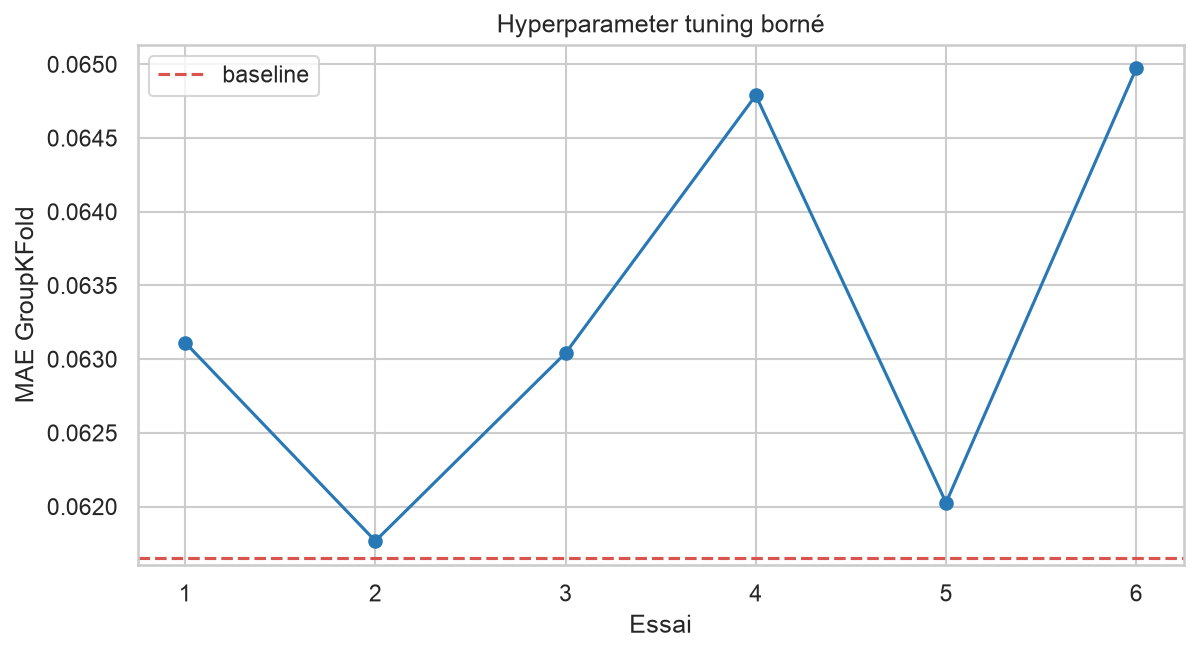

In [12]:
display(tables["tuning_trials"].sort_values("mae").head(6))
display(pd.Series(results["tuning_decision"], name="décision").to_frame())
display(Image(filename=str(results["paths"]["figure_tuning"])))

Six configurations XGBoost sont testées dans un espace borné sur les mêmes
folds groupés. Le meilleur essai ne bat pas la configuration figée ; le seuil
de gain matériel (0,0001 MAE) n'est donc pas atteint. Le tuning est rejeté.
Cette règle décidée avant publication évite de choisir une fluctuation de CV.

## 11. Interprétabilité et analyse d'erreurs

,feature,mae_increase_mean,mae_increase_std
0,killRank,0.265684,0.001345
1,walk_distance_per_match_minute,0.087231,0.000436
2,kills,0.075177,0.001647
3,maxRank,0.054242,0.000388
4,walkDist,0.016201,0.000232
5,mode_solo,0.009488,0.000238
6,mode_squad,0.008874,0.000221
7,mode_duo,0.008813,0.000289
8,damage_per_kill,0.003395,0.000287
9,upgrades,0.002217,0.000052


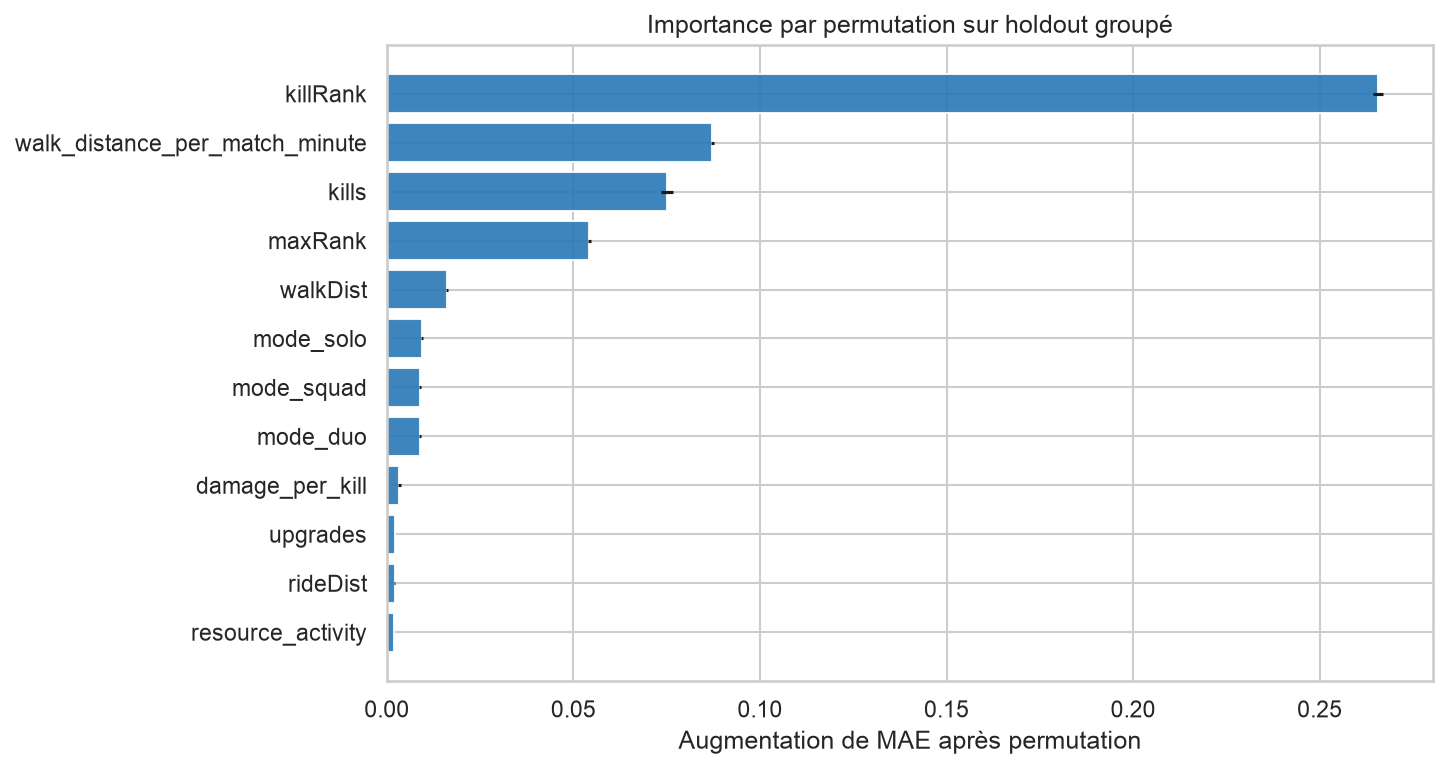

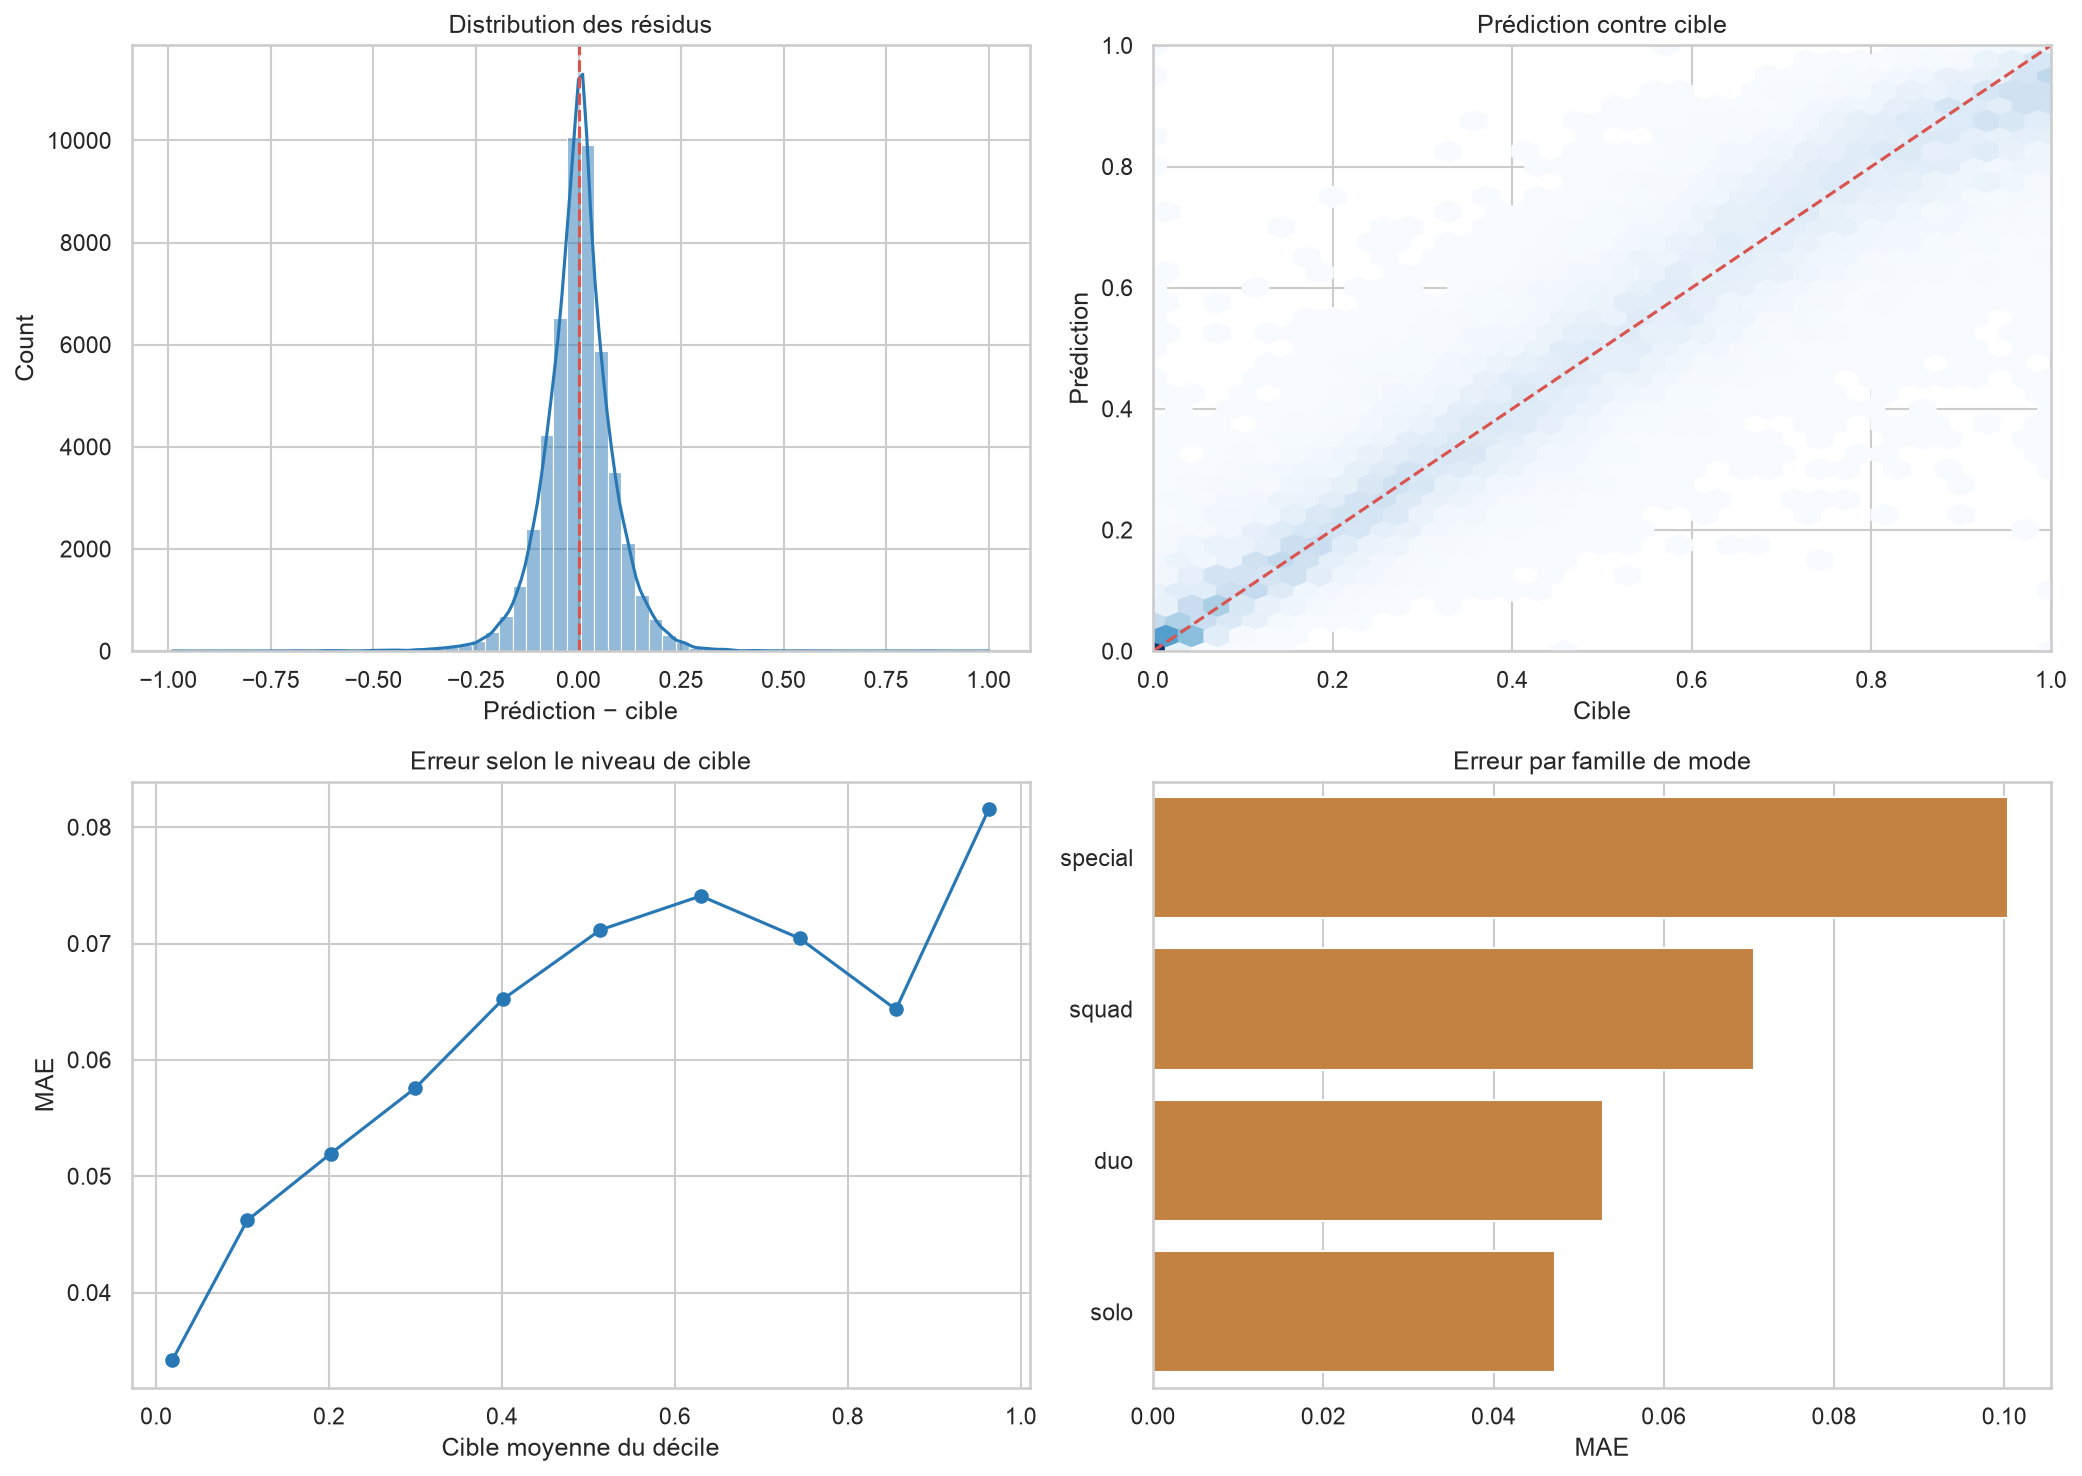

In [13]:
display(tables["permutation_importance"].head(16))
display(Image(filename=str(results["paths"]["figure_importance"])))
display(Image(filename=str(results["paths"]["figure_errors"])))

In [14]:
important_subgroups = tables["subgroup_errors"].query(
    "dimension in ['mode_family', 'rank_grid_size', 'target_band', 'kill_band']"
)
display(important_subgroups)
display(tables["largest_errors"].head(10))

,dimension,subgroup,rows,target_mean,prediction_mean,bias,mae,rmse
0,mode_family,duo,14897,0.485926,0.485807,-0.000119,0.052896,0.073937
1,mode_family,solo,7990,0.484519,0.485295,0.000776,0.047215,0.072417
2,mode_family,special,118,0.448151,0.469380,0.021230,0.100464,0.135995
3,mode_family,squad,26995,0.461330,0.461037,-0.000292,0.070583,0.096456
23,rank_grid_size,≤5,20,0.633335,0.582339,-0.050996,0.328955,0.390814
24,rank_grid_size,6–20,422,0.422072,0.433529,0.011457,0.175985,0.252071
25,rank_grid_size,21–80,41778,0.469794,0.469696,-0.000098,0.063504,0.087051
26,rank_grid_size,>80,7780,0.488278,0.488187,-0.000091,0.044807,0.062318
27,target_band,0–0.1,7080,0.035885,0.065381,0.029496,0.037363,0.067030
28,target_band,0.1–0.25,8140,0.174174,0.194194,0.020020,0.050170,0.071268


,playerId,teamId,gameId,gameType,maxRank,kills,damages,walkDist,rideDist,heals,weapons,gameTime,winRankPercentage,prediction,residual,absolute_error
0,bf9104d9f86113,8738398987e543,8d5c56ea372e42,solo,18,0,164.300000,0.000000,0.000000,0,7,1557,0.000000,1.000000,1.000000,1.000000
1,3d1593171f1ead,c807f2b326acae,abc9ec13d853f6,normal-duo-fpp,11,0,57.750000,0.000000,0.000000,0,2,899,1.000000,0.009963,-0.990037,0.990037
2,dde9486b06ba0b,98f8337ec1c14a,79dafc8cc6f755,solo,16,0,109.400000,0.000000,0.000000,0,10,1808,0.000000,0.935396,0.935396,0.935396
3,03a40fdefd4d9e,af22bc997af6bc,d0668068cfa369,solo,18,0,123.900000,0.000000,0.000000,0,7,1808,1.000000,0.106697,-0.893303,0.893303
4,b4e92a23f4e2c5,8596f1ace0a0e6,278f9c9cdc08b1,solo,17,0,499.200000,0.000000,0.000000,0,8,1808,0.000000,0.855069,0.855069,0.855069
5,f7857a1138dd79,f128c3bd9daeec,8dbc6b52521c0f,normal-squad,2,6,964.300000,156.500000,0.000000,11,20,883,0.000000,0.842364,0.842364,0.842364
6,aabc5408f1d00e,c6e53d91dc9fd4,fb9f622215e151,solo,16,0,0.000000,0.000000,0.000000,0,2,1771,0.000000,0.792896,0.792896,0.792896
7,9a9688a47775a0,af10740c58ac13,575e7b0988d426,squad,28,4,493.300000,202.200000,0.000000,2,1,1880,0.963000,0.196336,-0.766664,0.766664
8,fc0446bc5ecfd5,87b520de98dd6d,eae1670af29f15,solo,18,0,22.550000,0.000000,0.000000,0,6,1808,0.000000,0.717920,0.717920,0.717920
9,0ea2d714180675,56d9d6f8814a06,af08fed77a4683,solo,17,0,0.000000,0.000000,0.000000,0,10,1808,1.000000,0.296750,-0.703250,0.703250


La permutation confirme que `killRank` porte l'essentiel du signal post-match,
suivi de la mobilité, des kills et de `maxRank`. Les modes spéciaux et les
petites grilles affichent les erreurs les plus hautes, mais leurs effectifs sont
faibles : ce sont des alertes, pas des conclusions stables. Les résidus montrent
une régression vers la moyenne aux cibles élevées et quelques erreurs extrêmes ;
les cas les plus difficiles sont exportés pour inspection reproductible.

## 12. Contrat d'inférence

In [15]:
submission_check = predict_frame(
    results["test"],
    results["paths"]["model"],
)
assert list(submission_check.columns) == [
    "playerId", "teamId", "gameId", "winRankPercentage"
]
assert submission_check["winRankPercentage"].between(0, 1).all()
assert len(submission_check) == 5_000
display(submission_check.head())
display(pd.Series(results["paths"], name="chemin").tail(8).to_frame())

,playerId,teamId,gameId,winRankPercentage
0,fdb7d0af46a788,897c68f1df2b33,35ab88ab7516ad,0.833333
1,cfa5a4ed838e8f,e7d1e2c433debe,e05f33046a739f,0.750000
2,cbec92e083ebcd,52ff12219a050c,ba14752a861c4d,0.896552
3,94514c935686ac,6718223e4d7dfa,42c9e8ca738110,0.829787
4,a05a6b38045f65,372d871d4e82b7,e196ff3b6f8ced,0.565217


,chemin
figure_validation,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_ablation,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_models,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_tuning,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_errors,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_importance,/Users/surelmanda/GameLoft/refractor/Game-Play...
tuning_decision,/Users/surelmanda/GameLoft/refractor/Game-Play...
submission,/Users/surelmanda/GameLoft/refractor/Game-Play...


Le bundle impose l'ordre exact des 16 features, vérifie son SHA-256 et refuse
les colonnes officielles manquantes ou les prédictions non finies. La soumission
préserve l'ordre des 5 000 lignes et contient uniquement les trois identifiants
et la cible bornée/projetée sur la grille légale.

## 13. Conclusion, limites et prochaines étapes

Le pipeline final atteint une MAE GroupKFold d'environ **0,06165** et un R²
d'environ **0,9203** dans le scénario post-match. Sans `killRank`, la MAE
comportementale est d'environ **0,09326**. La principale conclusion n'est donc
pas seulement le score : `killRank` change la nature du cas d'usage.

Limites irréductibles : test sans cible, chronologie inutilisable, couverture
très partielle des matchs/équipes, faible support de certains modes et absence
de snapshots early-game. Pour un déploiement produit, il faut collecter une
date de match cohérente, les rosters complets, un split futur réellement
étiqueté et des variables disponibles au moment précis de la décision.